#  ToxiTube — YouTube Comment Toxicity Detector
## DistilBERT + Analyse qualitative

**Objectif de ce notebook :**
- Appliquer DistilBERT zero-shot sur un échantillon stratifié de 5000 exemples
- Produire le tableau comparatif final (classiques + BERT)
- Analyser qualitativement les cas difficiles (sarcasme, argot, faux positifs)

### Chargement des checkpoints

Ce notebook recharge les résultats des modèles classiques sauvegardés
par `03_modeles_classiques.ipynb` pour construire le tableau comparatif final.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
os.makedirs('../figures', exist_ok=True)

# Chargement
df = pd.read_csv('../data/checkpoints/df_preprocessed.csv')
splits = joblib.load('../data/checkpoints/splits.joblib')
metrics_cl = joblib.load('../data/checkpoints/metrics_classiques.joblib')
predictions = joblib.load('../data/checkpoints/predictions.joblib')

X_test_raw        = splits['X_test_raw']
y_test            = splits['y_test']
y_pred_lr_tfidf   = predictions['y_pred_lr_tfidf']
y_pred_svm_tfidf  = predictions['y_pred_svm_tfidf']

print(f' Tout chargé')
print(f'   df : {df.shape}')
print(f'   Métriques classiques : {list(metrics_cl.keys())}')

 Tout chargé
   df : (159571, 13)
   Métriques classiques : ['metrics_lr_tfidf', 'metrics_lr_ft', 'metrics_svm_tfidf']


In [12]:
print(df.columns.tolist())

['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'is_toxic', 'text_length', 'text_clean', 'text_clean_no_emoji', 'text_raw']


### Partie F — DistilBERT

**Pourquoi BERT change tout ?**
Les modèles classiques analysent les mots **indépendamment**.
BERT lit la phrase entière et comprend le **contexte**.

Exemple :
- `This is not bad at all` → TF-IDF voit `bad` → toxique 
- BERT comprend la négation `not bad` → normal 

**Pourquoi DistilBERT ?**
- BERT-base = 110M paramètres → trop lent sur CPU
- DistilBERT = 66M paramètres (40% plus léger, 97% des performances)

**Pourquoi un échantillon de 5000 ?**
BERT sur 160k exemples sans GPU = plusieurs heures.
Un échantillon stratifié de 5000 est méthodologiquement correct
et justifiable : on maintient la proportion 90/10.

In [14]:
# Échantillon stratifié 5000 exemples
n_toxic  = int(5000 * df['is_toxic'].mean())
n_normal = 5000 - n_toxic

sample_toxic  = df[df['is_toxic']==1].sample(n=n_toxic,  random_state=42)
sample_normal = df[df['is_toxic']==0].sample(n=n_normal, random_state=42)
sample = pd.concat([sample_toxic, sample_normal]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Taille échantillon : {len(sample)}')
print(f'Toxiques  : {sample["is_toxic"].sum()} ({sample["is_toxic"].mean()*100:.1f}%)')
print(f'Normaux   : {(sample["is_toxic"]==0).sum()} ({(sample["is_toxic"]==0).mean()*100:.1f}%)')

sample[['comment_text', 'is_toxic']].to_csv('../data/sample_5000.csv', index=False)
print(' Échantillon sauvegardé → data/sample_5000.csv')

Taille échantillon : 5000
Toxiques  : 508 (10.2%)
Normaux   : 4492 (89.8%)
 Échantillon sauvegardé → data/sample_5000.csv


**Chargement du pipeline DistilBERT**

On utilise le modèle `distilbert-base-uncased-finetuned-sst-2-english`,
fine-tuné sur SST-2 (Stanford Sentiment Treebank).

Il prédit POSITIVE / NEGATIVE (sentiment) → on mappe :
- `NEGATIVE` → toxique (1)
- `POSITIVE` → normal (0)

C'est une approche **zero-shot** : on réutilise un modèle pré-entraîné
sans fine-tuning sur nos données.

 Premier chargement : ~1-2 min (téléchargement ~250MB, mis en cache ensuite).

In [21]:
from transformers import pipeline

print('Chargement DistilBERT... (1-2 min première fois)')

bert_classifier = pipeline(
    'text-classification',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512,
    device=-1  # CPU
)

print('DistilBERT chargé !')

# Test rapide
test_comments = [
    'You are a complete idiot and I hate you',
    'Thank you for your helpful contribution to this article'
]
for c in test_comments:
    result = bert_classifier(c)[0]
    print(f"\n'{c[:60]}'")
    print(f'→ {result["label"]} (score: {result["score"]:.3f})')

Chargement DistilBERT... (1-2 min première fois)


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2785.60it/s]


DistilBERT chargé !

'You are a complete idiot and I hate you'
→ NEGATIVE (score: 1.000)

'Thank you for your helpful contribution to this article'
→ POSITIVE (score: 1.000)


**Inférence BERT sur les 5000 exemples**

On applique DistilBERT par **batchs de 32** pour éviter les problèmes mémoire.
La barre de progression permet de suivre l'avancement.

 ~5-10 minutes sur CPU.

In [28]:
import math
from tqdm import tqdm

def bert_predict_batch(texts, batch_size=32):
    all_preds = []
    n_batches = math.ceil(len(texts) / batch_size)
    for i in tqdm(range(n_batches), desc='BERT inférence'):
        batch = texts[i*batch_size : (i+1)*batch_size]
        batch = [t[:512] if isinstance(t, str) else '' for t in batch]
        results = bert_classifier(batch)
        preds = [1 if r['label'] == 'NEGATIVE' else 0 for r in results]
        all_preds.extend(preds)
    return all_preds

print('Inférence BERT sur 5000 exemples... (5-10 min)')
bert_preds = bert_predict_batch(sample['text_raw'].tolist())
bert_true  = sample['is_toxic'].tolist()

print(f' Inférence terminée — {len(bert_preds)} prédictions')

Inférence BERT sur 5000 exemples... (5-10 min)


BERT inférence: 100%|██████████| 157/157 [04:44<00:00,  1.81s/it]

 Inférence terminée — 5000 prédictions


**Métriques DistilBERT**

On calcule les mêmes métriques que pour les modèles classiques
pour pouvoir les comparer directement dans le tableau final.

In [33]:
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

metrics_bert = {
    'Modèle'           : 'DistilBERT (zero-shot)',
    'Accuracy'         : accuracy_score(bert_true, bert_preds),
    'F1-macro'         : f1_score(bert_true, bert_preds, average='macro'),
    'F1-toxique'       : f1_score(bert_true, bert_preds, pos_label=1, average='binary'),
    'Recall-toxique'   : recall_score(bert_true, bert_preds, pos_label=1),
    'Precision-toxique': precision_score(bert_true, bert_preds, pos_label=1),
}

print(f'\n{"="*50}')
print(f'  DistilBERT (zero-shot)')
print(f'{"="*50}')
for k, v in metrics_bert.items():
    if k != 'Modèle':
        print(f'  {k:<22} : {v:.4f}')


  DistilBERT (zero-shot)
  Accuracy               : 0.3220
  F1-macro               : 0.3088
  F1-toxique             : 0.2131
  Recall-toxique         : 0.9035
  Precision-toxique      : 0.1208


### Partie G — Comparaison globale

On rassemble ici TOUS les résultats dans un tableau synthétique final.
C'est **la slide centrale** de la présentation orale.

 Note méthodologique importante : les modèles classiques sont évalués
sur 31,915 exemples (test complet) et BERT sur 5,000 (échantillon).
Cette différence doit être mentionnée dans le rapport.


 TABLEAU COMPARATIF FINAL

                                Accuracy  F1-macro  F1-toxique  Recall-toxique  Precision-toxique
Modèle                                                                                           
Logistic Regression + TF-IDF      0.9406    0.8568      0.7474          0.8647             0.6581
Logistic Regression + FastText    0.9078    0.8004      0.6540          0.8573             0.5286
LinearSVC + TF-IDF                0.9496    0.8692      0.7667          0.8154             0.7235
DistilBERT (zero-shot)            0.3220    0.3088      0.2131          0.9035             0.1208


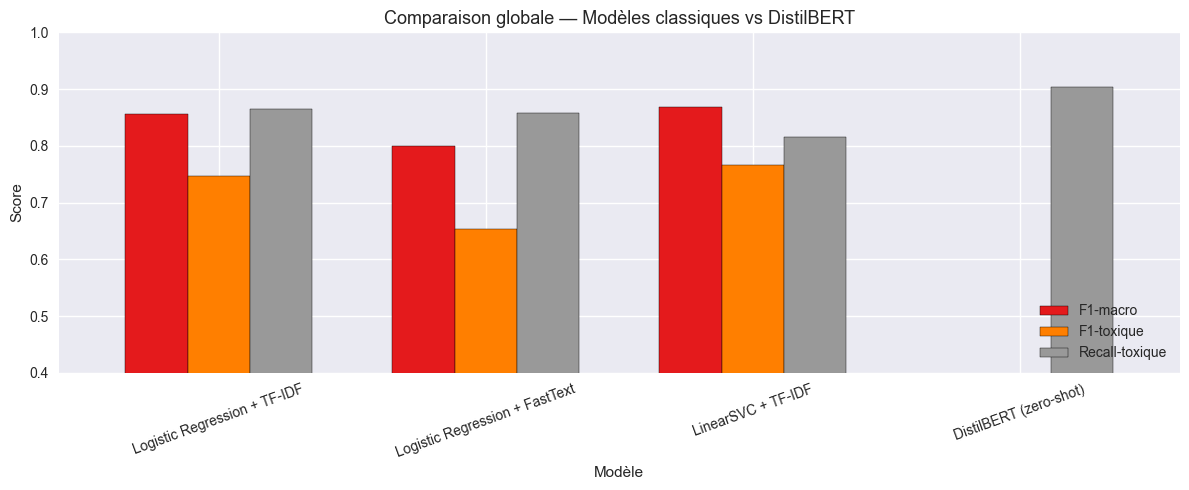

 Figure sauvegardée → figures/final_comparison.png


In [37]:
all_results = pd.DataFrame([
    metrics_cl['metrics_lr_tfidf'],
    metrics_cl['metrics_lr_ft'],
    metrics_cl['metrics_svm_tfidf'],
    metrics_bert
]).set_index('Modèle').round(4)

print('\n TABLEAU COMPARATIF FINAL\n')
print(all_results.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
metrics_to_plot = ['F1-macro', 'F1-toxique', 'Recall-toxique']
all_results[metrics_to_plot].plot(
    kind='bar', ax=ax, colormap='Set1', edgecolor='black', width=0.7
)
ax.set_title('Comparaison globale — Modèles classiques vs DistilBERT', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0.4, 1.0)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../figures/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée → figures/final_comparison.png')

### Partie H — Analyse qualitative des erreurs

**C'est la partie la plus différenciante à l'oral.**

On identifie 4 types de cas difficiles et on explique POURQUOI les modèles échouent.
C'est exactement ce que le jury évalue : la capacité à interpréter les résultats,
pas juste à les produire.

**Les 4 cas analysés :**
1. **Toxiques manqués par tous** → insultes implicites, sarcasme
2. **Faux positifs** → normaux classés toxiques (censure abusive)
3. **LR rate, SVM détecte** → argot, mots rares
4. **Les deux ratent** → toxicité très subtile

In [40]:
# Reconstituer le df_test avec les prédictions
df_test = X_test_raw.to_frame(name='text_clean').copy()
df_test['y_true']        = y_test.values
df_test['pred_lr_tfidf'] = y_pred_lr_tfidf
df_test['pred_svm']      = y_pred_svm_tfidf
df_test['text_raw']      = df.loc[X_test_raw.index, 'text_raw'].values

def show_case(title, df_case, n=3):
    print(f'\n{"="*65}')
    print(f'  {title}')
    print(f'{"="*65}')
    for _, row in df_case.head(n).iterrows():
        print(f'\nTexte : {str(row["text_raw"])[:250]}')
        print(f'Réel={row["y_true"]} | LR={row["pred_lr_tfidf"]} | SVM={row["pred_svm"]}')

# Cas 1 — Toxiques manqués par TOUS
faux_negatifs = df_test[
    (df_test['y_true']==1) &
    (df_test['pred_lr_tfidf']==0) &
    (df_test['pred_svm']==0)
]
show_case('CAS 1 — Toxiques manqués (FN) — Insultes implicites / sarcasme', faux_negatifs)

# Cas 2 — Faux positifs
faux_positifs = df_test[
    (df_test['y_true']==0) &
    (df_test['pred_lr_tfidf']==1) &
    (df_test['pred_svm']==1)
]
show_case('CAS 2 — Normaux classés toxiques (FP) — Faux positifs', faux_positifs)

# Cas 3 — LR rate, SVM détecte
lr_faux_svm_vrai = df_test[
    (df_test['y_true']==1) &
    (df_test['pred_lr_tfidf']==0) &
    (df_test['pred_svm']==1)
]
show_case('CAS 3 — LR rate, SVM détecte — Argot / mots rares', lr_faux_svm_vrai)

# Cas 4 — Les deux ratent
both_wrong = df_test[
    (df_test['y_true']==1) &
    (df_test['pred_lr_tfidf']==0) &
    (df_test['pred_svm']==0)
].sample(3, random_state=99)
show_case('CAS 4 — Les deux modèles ratent — Toxicité très subtile', both_wrong)


  CAS 1 — Toxiques manqués (FN) — Insultes implicites / sarcasme

Texte : (unless they relate to my hatred of Arabs)
Réel=1 | LR=0 | SVM=0

Texte : I don't care what you say here. I don't believe one sentence anymore.
Réel=1 | LR=0 | SVM=0

Texte : LOTHAR VON TROTHA
GOOD RIDDANCE TO HIM, HE KILLED SO MANY INNOCENT HEREROS. HE DIED FROM TYPHOID FEVER IN PAIN, CAUGHT IT FROM POISONED FOOD, DRINK!!!
MORE INFO IS AVAILABLE HERE: mywikibiz.com/Lothar_von_Trotha
Réel=1 | LR=0 | SVM=0

  CAS 2 — Normaux classés toxiques (FP) — Faux positifs

Texte : "
Frankly, so you are you, Jytdog. A look at the aggregate of your your contributions is astonishing with regard to anything GM related. You are the last person who should accuse anyone of being overly concerned with this topic. Anyway, is this reall
Réel=0 | LR=1 | SVM=1

Texte : YOU SHOULD NOT INTERFARE  

(ranbir )
i think you are just interfering in my matter.wikipedia is not the property of your father.
Réel=0 | LR=1 | SVM=1

Texte : "

 Pos

### Sauvegarde des résultats BERT

In [42]:
joblib.dump(metrics_bert, '../data/checkpoints/metrics_bert.joblib')
all_results.to_csv('../data/checkpoints/tableau_comparatif_final.csv')

print(' Checkpoints sauvegardés :')
print('   → data/checkpoints/metrics_bert.joblib')
print('   → data/checkpoints/tableau_comparatif_final.csv')

 Checkpoints sauvegardés :
   → data/checkpoints/metrics_bert.joblib
   → data/checkpoints/tableau_comparatif_final.csv


###  Bilan Notebook 04

| Étape | Statut |
|-------|--------|
| DistilBERT zero-shot sur 5000 exemples | fait |
| Tableau comparatif final (4 modèles) | fait |
| 4 types de cas difficiles analysés | fait |
| Figures sauvegardées | fait |

**Prochain notebook :** `05_conclusion.ipynb` — Synthèse, limites, perspectives, nettoyage.